In [ ]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6


In [11]:
windowsize_list='100 500 1000 3000 6000 10000 15000 20000 30000 50000 80000 100000 200000 400000 800000'
ws_list = list(map(int, windowsize_list.split()))

entropy_ws_pdir = '/mnt/hdd_bob/syy/adipose/atac/res'

sample_list = ['VIB_10xmultiome_2', 'human_brain2_3k', 'mouse_cryo_brain_5k', 'human_10k_1', 'mice_brain_5k']
Ncells_list = {}

# sample='VIB_10xmultiome_2'
for sample in sample_list:
    
    Ncells_list[sample] = []
    for ws in ws_list:
        entropy_dir = os.path.join(entropy_ws_pdir, f'_{sample}_WS{ws}')
        entropy_cutoff_file = os.path.join(entropy_dir, 'entropy_cutoff.csv')
        if not os.path.exists(entropy_cutoff_file):
            print(f'Entropy cutoff file not found for window size {ws}. Skipping.')
            continue
        with open(entropy_cutoff_file, 'r') as f:
            
            cutoff_value = f.read().split('\n')[-2].split(',')
            print(f'{sample}, Window size: {ws}, {cutoff_value}')
            Ncells_list[sample].append(int(int(cutoff_value[1])))


VIB_10xmultiome_2, Window size: 100, ['rank cutoff', '376']
VIB_10xmultiome_2, Window size: 500, ['rank cutoff', '2127']
VIB_10xmultiome_2, Window size: 1000, ['rank cutoff', '2122']
VIB_10xmultiome_2, Window size: 3000, ['rank cutoff', '2125']
VIB_10xmultiome_2, Window size: 6000, ['rank cutoff', '2124']
VIB_10xmultiome_2, Window size: 10000, ['rank cutoff', '2123']
VIB_10xmultiome_2, Window size: 15000, ['rank cutoff', '2126']
VIB_10xmultiome_2, Window size: 20000, ['rank cutoff', '2133']
VIB_10xmultiome_2, Window size: 30000, ['rank cutoff', '2232']
VIB_10xmultiome_2, Window size: 50000, ['rank cutoff', '2273']
VIB_10xmultiome_2, Window size: 80000, ['rank cutoff', '2289']
VIB_10xmultiome_2, Window size: 100000, ['rank cutoff', '2284']
VIB_10xmultiome_2, Window size: 200000, ['rank cutoff', '2327']
VIB_10xmultiome_2, Window size: 400000, ['rank cutoff', '2360']
VIB_10xmultiome_2, Window size: 800000, ['rank cutoff', '3638']
human_brain2_3k, Window size: 100, ['rank cutoff', '3387']


# Figure

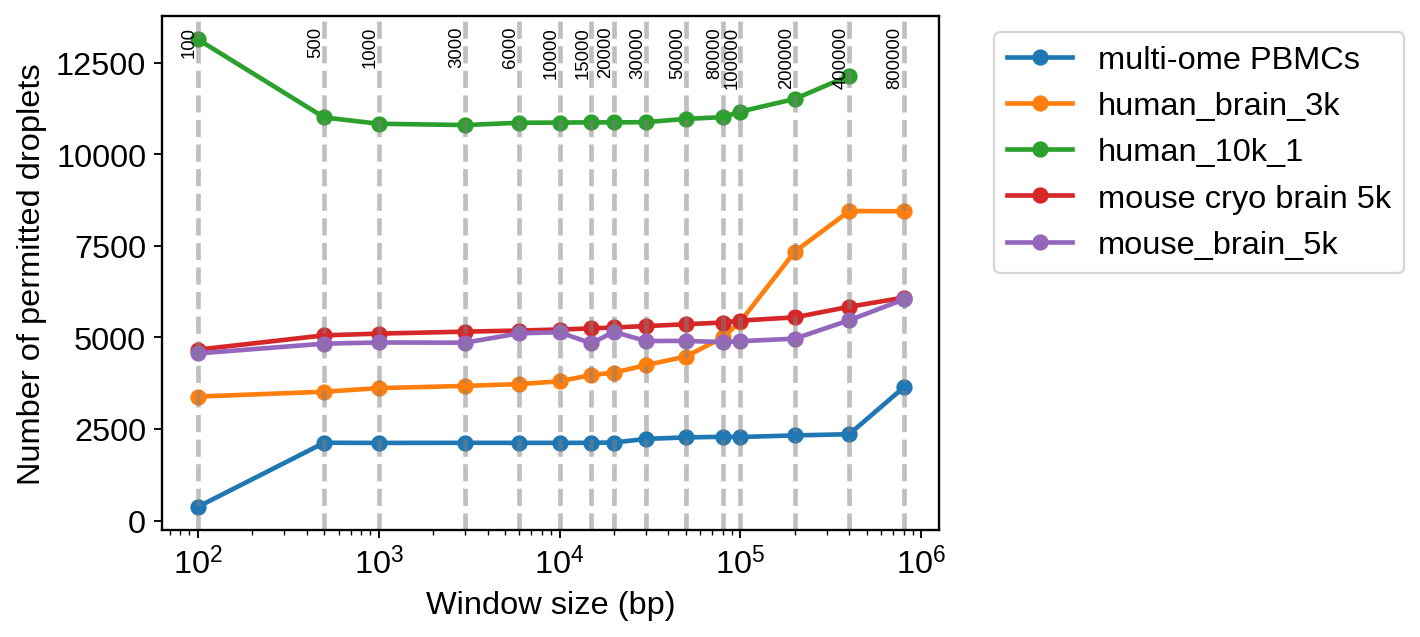

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
_ = ax.plot(ws_list[:len(Ncells_list['VIB_10xmultiome_2'])], Ncells_list['VIB_10xmultiome_2'], marker='o', label='multi-ome PBMCs')
_ = ax.plot(ws_list[:len(Ncells_list['human_brain2_3k'])], Ncells_list['human_brain2_3k'], marker='o', label='human_brain_3k')
_ = ax.plot(ws_list[:len(Ncells_list['human_10k_1'])], Ncells_list['human_10k_1'], marker='o', label='human_10k_1')
_ = ax.plot(ws_list[:len(Ncells_list['mouse_cryo_brain_5k'])], Ncells_list['mouse_cryo_brain_5k'], marker='o', label='mouse cryo brain 5k')
_ = ax.plot(ws_list[:len(Ncells_list['mice_brain_5k'])], Ncells_list['mice_brain_5k'], marker='o', label='mouse_brain_5k')
ax.set_xscale('log')
ax.set_xlabel('Window size (bp)')
ax.set_ylabel('Number of permitted droplets')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for ws in ws_list:
    ax.axvline(x=ws, color='gray', linestyle='--', alpha=0.5)
    ax.text(ws, ax.get_ylim()[1]*0.98, str(ws), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=8)